# Benchmark contra el flujo heredado: ¿predecimos mejor que lo que ya existía?

## Qué responde este notebook

Antes de este proyecto ya había un flujo que predecía cada semana las recepciones, yardas y
touchdowns de los receptores (sus notebooks están en `weekly/wr/notebooks/_reference/`). La
pregunta es si los modelos elegidos en la etapa 4 predicen mejor. Se responde en dos niveles:

1. Poner en contexto las métricas que el propio flujo heredado reportó.
2. La comparación más directa posible: sus predicciones guardadas para las semanas 7-18 de 2025
   contra lo que pasó, y el modelo nuevo prediciendo exactamente los mismos jugadores y semanas.

El flujo heredado se evaluaba con MAE, así que se reporta MAE para que las cifras sean comparables
con las suyas. La comparación que cuenta usa la métrica principal de cada resultado (RMSE en
recepciones y yardas, deviance de Poisson en touchdowns) y el R² fuera de muestra, por las razones
de [`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb).

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling, experimentos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"
TARGETS = ["receptions", "receiving_yards", "receiving_tds"]

## 1. Lo que el flujo heredado reportó

Cada notebook de `_reference/` (`wrs_rec_tds.ipynb`, `wrs_rec_yds.ipynb`, `wrs_receptions.ipynb`)
entrena un XGBoost sin baseline ni alternativas, con `train_test_split(test_size=0.1,
random_state=42)`: una partición **aleatoria**, no temporal, sobre semanas de cualquier temporada.
Las cifras siguientes son las de sus celdas de salida.

In [2]:
metricas_legado_reportadas = pd.DataFrame({
    "receptions":       {"train_mae": 0.0412, "train_r2": 0.9994, "test_mae": 1.8119, "test_r2": 0.1922},
    "receiving_yards":  {"train_mae": 0.6678, "train_r2": 0.9992, "test_mae": 28.8467, "test_r2": 0.1134},
    "receiving_tds":    {"train_mae": 0.0086, "train_r2": 0.9994, "test_mae": 0.4233, "test_r2": -0.0868},
}).T
metricas_legado_reportadas

,train_mae,train_r2,test_mae,test_r2
receptions,0.0412,0.9994,1.8119,0.1922
receiving_yards,0.6678,0.9992,28.8467,0.1134
receiving_tds,0.0086,0.9994,0.4233,-0.0868


**Lectura.** El R² de entrenamiento es mayor a 0.999 en los tres: el modelo memoriza el entrenamiento. El R²
negativo de `receiving_tds` en su propia prueba significa que predice peor que el promedio, aun con
una partición aleatoria, que es más fácil que una temporal porque dos semanas del mismo jugador
pueden quedar una en entrenamiento y otra en prueba.

## 2. Las predicciones guardadas de 2025 tienen filas duplicadas

`weekly/wr/outputs/2025/` guarda las predicciones del flujo heredado para las semanas 7-18 de 2025:
tres archivos por semana (uno por resultado) y uno que los junta. Antes de usarlas se revisa si hay
más de una fila por jugador y semana.

In [3]:
resumen_dup = []
archivos_por_target = {
    "receptions": ("wrs_receptions", "predicted_receptions"),
    "receiving_yards": ("wrs_rec_yds", "predicted_receiving_yards"),
    "receiving_tds": ("wrs_rec_tds", "predicted_receiving_tds"),
}
for semana in range(7, 19):
    for target, (prefijo, col) in archivos_por_target.items():
        df = pd.read_csv(f"../outputs/2025/{prefijo}_pred_week_{semana}.csv")
        resumen_dup.append({
            "semana": semana, "target": target, "filas": len(df),
            "jugadores_unicos": df["player_id"].nunique(),
            "factor_duplicacion": len(df) / df["player_id"].nunique(),
        })
resumen_dup = pd.DataFrame(resumen_dup)
resumen_dup.pivot(index="semana", columns="target", values="factor_duplicacion").round(2)

target,receiving_tds,receiving_yards,receptions
semana,,,
7,1.00,1.00,1.00
8,1.00,1.00,1.00
9,1.89,1.00,1.00
10,1.00,1.00,1.00
11,1.02,1.02,1.02
12,2.00,2.00,2.00
13,1.05,1.05,1.05
14,1.06,1.06,1.06
15,1.06,1.06,1.06


**Lectura.** Las semanas 7, 8 y 10 no tienen duplicados; la 9 duplica solo touchdowns (1.89 filas
por jugador); la 11 y de la 13 a la 17 duplican poco (1.02-1.06); la 12 tiene en promedio dos filas
por jugador (2.00) y la 18, 1.85, en los tres resultados. No es un patrón uniforme. Una explicación posible es
que algunas corridas del flujo heredado guardaron más de una alineación del mismo día para la misma
semana.

Para saber si da igual qué fila tomar, se mide qué tan distintas son las predicciones duplicadas en
las dos semanas más duplicadas (12 y 18), en los tres resultados.

In [4]:
filas_dispersion = []
for semana in (12, 18):
    for target, (prefijo, col) in archivos_por_target.items():
        df = pd.read_csv(f"../outputs/2025/{prefijo}_pred_week_{semana}.csv")
        por_jugador = df.groupby("player_id")[col].agg(["count", "mean", "std"])
        por_jugador = por_jugador[por_jugador["count"] > 1]
        cv = (por_jugador["std"] / por_jugador["mean"]).abs()
        filas_dispersion.append({
            "semana": semana, "target": target, "jugadores_con_duplicado": len(por_jugador),
            "filas_por_jugador": ", ".join(str(n) for n in sorted(por_jugador["count"].unique())),
            "duplicados_identicos": int((por_jugador["std"] == 0).sum()),
            "cv_mediana": cv.median(), "cv_promedio": cv.mean(), "cv_maximo": cv.max(),
        })
pd.DataFrame(filas_dispersion).round(3)

,semana,target,jugadores_con_duplicado,filas_por_jugador,duplicados_identicos,cv_mediana,cv_promedio,cv_maximo
0,12,receptions,76,"2, 3, 5",0,0.073,0.100,0.428
1,12,receiving_yards,76,"2, 3, 5",0,0.103,0.128,0.512
2,12,receiving_tds,76,"2, 3, 5",0,0.159,0.252,1.645
3,18,receptions,77,"2, 3",0,0.100,0.118,0.375
4,18,receiving_yards,77,"2, 3",0,0.109,0.125,0.403
5,18,receiving_tds,77,"2, 3",0,0.266,0.383,2.773


**Lectura.** En las dos semanas, ningún jugador con filas duplicadas tiene predicciones idénticas:
son 76 jugadores en la semana 12 (con 2, 3 o 5 filas) y 77 en la 18 (con 2 o 3). La dispersión
entre sus predicciones (coeficiente de variación) tiene medianas de 7.3% a 10.9% en recepciones y
yardas, y de 15.9% y 26.6% en touchdowns, donde llega a 277% en la semana 18: no es ruido de
redondeo, y tomar la primera fila que aparezca metería un error arbitrario. La regla es promediar
los duplicados de cada jugador y semana; no corrige el problema de origen, pero da una cifra
comparable.

## 3. Predicciones del flujo heredado, deduplicadas, contra el resultado real

In [5]:
piezas = []
for semana in range(7, 19):
    dfs = {}
    for target, (prefijo, col) in archivos_por_target.items():
        df = pd.read_csv(f"../outputs/2025/{prefijo}_pred_week_{semana}.csv")
        dfs[target] = df.groupby("player_id")[col].mean()
    tabla = pd.DataFrame(dfs)
    tabla["week"] = semana
    piezas.append(tabla.reset_index())
legado = pd.concat(piezas, ignore_index=True)
legado["season"] = 2025
print(f"legado deduplicado: {legado.shape[0]} filas, {legado['player_id'].nunique()} jugadores únicos")

stats_2025 = data.cargar_stats_semanales([2025])
real = stats_2025[stats_2025["position"] == "WR"][["player_id", "season", "week"] + list(modeling.TARGETS)]
cruce = legado.merge(real, on=["player_id", "season", "week"], how="inner", suffixes=("_pred", "_real"))
print(f"filas del legado con resultado real como WR: {cruce.shape[0]} de {legado.shape[0]}")

sin_real = legado.merge(real[["player_id", "season", "week"]], on=["player_id", "season", "week"], how="left", indicator=True)
sin_real = sin_real[sin_real["_merge"] == "left_only"]
filas_semana = stats_2025[["player_id", "season", "week", "position"]].drop_duplicates(["player_id", "season", "week"])
otra_posicion = sin_real.merge(filas_semana, on=["player_id", "season", "week"], how="inner")
print(f"sin resultado como WR: {len(sin_real)}; con fila en las estadisticas de esa semana en otra posicion: "
      f"{len(otra_posicion)} {otra_posicion['position'].value_counts().to_dict()}; sin ninguna fila esa semana "
      f"(no jugo o no registro estadisticas): {len(sin_real) - len(otra_posicion)}")

legado deduplicado: 1077 filas, 142 jugadores únicos
filas del legado con resultado real como WR: 929 de 1077
sin resultado como WR: 148; con fila en las estadisticas de esa semana en otra posicion: 1 {'CB': 1}; sin ninguna fila esa semana (no jugo o no registro estadisticas): 147


**Lectura.** Al promediar los duplicados quedan 1,077 filas de 142 receptores, y 929 tienen resultado
real como WR. De las 148 restantes, 147 no tienen ninguna fila en las estadísticas de esa semana (el
receptor no jugó o no registró ninguna estadística) y 1 aparece en otra posición. La comparación se
hace sobre esas 929 filas.

## 4. El modelo nuevo sobre exactamente las mismas filas

Se entrena la configuración elegida en
[`4.4_ajuste_hiperparametros.ipynb`](4.4_ajuste_hiperparametros.ipynb) con toda la historia hasta
2024 y se predicen las filas de 2025 que también predijo el flujo heredado. Las métricas de los dos
se calculan sobre las mismas filas, y el R² fuera de muestra de ambos usa la misma referencia: la
media de 2016-2024.

In [6]:
CONFIG_ELEGIDA = {
    "receptions": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_yards": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_tds": dict(objective="count:poisson", max_depth=3, n_estimators=200, learning_rate=0.08),
}

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
train_hasta_2024 = wr["season"] <= 2024

filas_2025 = wr[wr["season"] == 2025].reset_index(drop=True)
comparables = filas_2025.merge(
    cruce[["player_id", "week"] + [f"{t}_pred" for t in modeling.TARGETS]], on=["player_id", "week"], how="inner"
)
print(f"filas en las que se pueden comparar los dos: {len(comparables)} de {len(cruce)} con resultado real")

filas = {}
for target in modeling.TARGETS:
    modelo = XGBRegressor(**CONFIG_ELEGIDA[target], random_state=0, n_jobs=-1)
    modelo.fit(wr.loc[train_hasta_2024, features_arbol], wr.loc[train_hasta_2024, target])
    comparables[f"{target}_nuevo"] = modeling.clip_no_negativo(modelo.predict(comparables[features_arbol]))
    media = wr.loc[train_hasta_2024, target].mean()
    principal = modeling.METRICA_PRINCIPAL[target]
    validas = comparables[target].notna() & comparables[f"{target}_pred"].notna()
    datos = comparables[validas]
    m_legado = modeling.metricas_target(target, datos[target], datos[f"{target}_pred"], media)
    m_nuevo = modeling.metricas_target(target, datos[target], datos[f"{target}_nuevo"], media)
    c = experimentos.diferencia_bootstrap(datos, datos[target], datos[f"{target}_nuevo"], datos[f"{target}_pred"], principal)
    filas[target] = {
        "n": int(validas.sum()), "metrica_principal": principal,
        "legado_principal": m_legado[principal], "nuevo_principal": m_nuevo[principal],
        "dif_nuevo_menos_legado": c["diferencia"], "IC_inf": c["ic_inferior"], "IC_sup": c["ic_superior"],
        "legado_r2_oos": m_legado["r2_oos"], "nuevo_r2_oos": m_nuevo["r2_oos"],
        "legado_mae": m_legado["mae"], "nuevo_mae": m_nuevo["mae"],
        "legado_sesgo": m_legado["sesgo"], "nuevo_sesgo": m_nuevo["sesgo"],
    }
comparacion_final = pd.DataFrame(filas).T.infer_objects()
comparacion_final.round(4)

filas en las que se pueden comparar los dos: 929 de 929 con resultado real


,n,metrica_principal,legado_principal,nuevo_principal,dif_nuevo_menos_legado,IC_inf,IC_sup,legado_r2_oos,nuevo_r2_oos,legado_mae,nuevo_mae,legado_sesgo,nuevo_sesgo
receptions,924,rmse,2.1884,2.1332,-0.0552,-0.1142,-0.0003,0.2682,0.3046,1.7222,1.6520,0.1919,-0.0201
receiving_yards,924,rmse,34.4209,32.6078,-1.8131,-2.8451,-0.8782,0.1702,0.2553,27.0493,25.3156,3.3852,-0.1393
receiving_tds,926,deviance_poisson,0.9445,0.7718,-0.1727,-0.3022,-0.0760,-0.0312,0.0532,0.4122,0.3949,0.0237,-0.0037


Son tres comparaciones a la vez, una por resultado, así que con la regla de
[`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb) cada intervalo se ajusta a un
nivel de 1 − 0.05 / 3 (Bonferroni).

In [7]:
nivel = 1 - 0.05 / len(modeling.TARGETS)
for target in modeling.TARGETS:
    principal = modeling.METRICA_PRINCIPAL[target]
    datos = comparables[comparables[target].notna() & comparables[f"{target}_pred"].notna()]
    c = experimentos.diferencia_bootstrap(datos, datos[target], datos[f"{target}_nuevo"], datos[f"{target}_pred"], principal,
                                          n_remuestreos=20000, nivel=nivel)
    print(f"{target}: nuevo menos heredado = {c['diferencia']:+.4f}, intervalo de {nivel:.1%}: "
          f"{c['ic_inferior']:+.4f} a {c['ic_superior']:+.4f} -> "
          f"{'empate' if c['empate'] else ('mejora real' if c['diferencia'] < 0 else 'empeora')}")

receptions: nuevo menos heredado = -0.0552, intervalo de 98.3%: -0.1301 a +0.0067 -> empate
receiving_yards: nuevo menos heredado = -1.8131, intervalo de 98.3%: -3.0838 a -0.6572 -> mejora real
receiving_tds: nuevo menos heredado = -0.1727, intervalo de 98.3%: -0.3334 a -0.0595 -> mejora real


**Lectura.** Sobre las mismas filas, el modelo nuevo tiene mejor métrica principal, mejor R² fuera de muestra y
mejor MAE que el flujo heredado en los tres resultados:

| Resultado | Métrica principal (heredado → nuevo) | IC de la diferencia, 95% | IC ajustado, 98.3% | R² fuera de muestra | MAE |
|---|---|---|---|---|---|
| `receptions` | RMSE 2.188 → 2.133 | −0.114 a −0.0003 | −0.130 a +0.007 | 0.268 → 0.305 | 1.722 → 1.652 |
| `receiving_yards` | RMSE 34.42 → 32.61 | −2.85 a −0.88 | −3.08 a −0.66 | 0.170 → 0.255 | 27.05 → 25.32 |
| `receiving_tds` | deviance 0.9445 → 0.7718 | −0.302 a −0.076 | −0.3334 a −0.0595 | −0.031 → 0.053 | 0.412 → 0.395 |

Con el ajuste por las tres comparaciones, la mejora es real en yardas y en touchdowns. En recepciones
el intervalo de 95% apenas excluye el cero y el ajustado lo incluye: ahí la ventaja de 0.055 en RMSE
no se distingue del ruido de 12 semanas.

Dos diferencias adicionales. En promedio, el flujo heredado sobreestimaba (+0.19 recepciones y
+3.4 yardas por receptor); el nuevo tiene un sesgo mucho menor (−0.02 recepciones y −0.14 yardas). Y
en touchdowns el heredado queda por debajo del promedio histórico (R² negativo), mientras que el
nuevo lo supera.

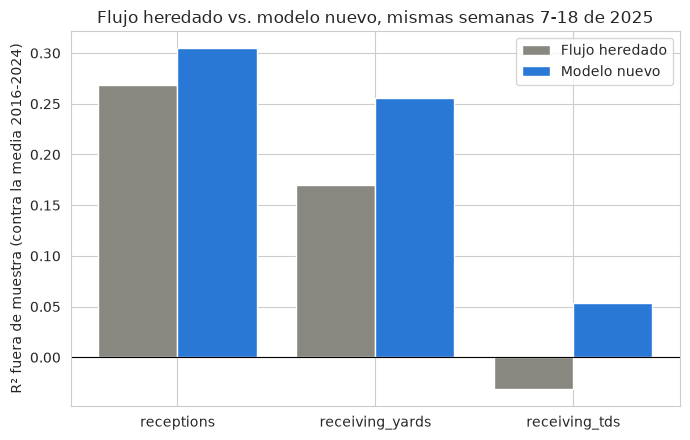

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(modeling.TARGETS))
ax.bar(x - 0.2, comparacion_final["legado_r2_oos"].astype(float), width=0.4, label="Flujo heredado", color=GRIS)
ax.bar(x + 0.2, comparacion_final["nuevo_r2_oos"].astype(float), width=0.4, label="Modelo nuevo", color=AZUL)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(modeling.TARGETS)
ax.set_ylabel("R² fuera de muestra (contra la media 2016-2024)")
ax.set_title("Flujo heredado vs. modelo nuevo, mismas semanas 7-18 de 2025")
ax.legend()
plt.tight_layout()
plt.show()

## Cierre

Con las mismas semanas 7-18 de 2025 y los mismos receptores que el flujo heredado predijo en su
momento, el modelo nuevo es mejor en yardas y en touchdowns, con diferencias que no son ruido aun
ajustando por las tres comparaciones. En recepciones también es mejor en la estimación puntual (RMSE,
R² fuera de muestra y MAE), pero con el intervalo ajustado la diferencia no se distingue del ruido.
Mejora en MAE en los tres, la métrica con la que se evaluaba el flujo heredado, así que la conclusión
no depende de haber cambiado de métrica. En touchdowns, el heredado predecía peor que el promedio
histórico y el nuevo no.

Anterior: [`5.1_estabilidad_temporal.ipynb`](5.1_estabilidad_temporal.ipynb) · Siguiente:
[`5.3_explicabilidad_y_casos.ipynb`](5.3_explicabilidad_y_casos.ipynb)